# 02 — Entrenamiento y Comparación de Modelos

**Fase 1B.** Nueve algoritmos entrenados con `RandomizedSearchCV` (StratifiedKFold, scoring ROC-AUC) sobre el split 60/20/20. Métricas con énfasis clínico; el objetivo NO es maximizar *accuracy* (engañosa con desbalance) sino la **discriminación** (ROC-AUC, PR-AUC) y la base para probabilidades fiables.

In [1]:
# --- Setup: rutas y utilidades de presentación ---
import sys, json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display, Markdown

BR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(BR / "src"))
sys.path.insert(0, str(BR.parent / "src"))
from predia_brfss import config, codebook

RES = BR / "results"
def show(p, w=None):
    display(Image(filename=str(p), width=w))
def table(csv, **kw):
    return pd.read_csv(csv, **kw)
def load(j):
    return json.load(open(j))
pd.set_option("display.max_columns", 40)
print("Entorno listo:", BR)


Entorno listo: /home/wowo/Descargas/predia/ml-research/brfss


## Tabla comparativa (conjunto de validación)
Ordenada por ROC-AUC. `pr_auc` y `brier` son especialmente informativos con prevalencia baja. Métricas de umbral (f1/precision/recall) calculadas a t=0.5 (la umbralización clínica se aborda en el NB 04).

In [2]:
comp = table(RES/'models'/'comparison.csv'); comp

,model,roc_auc,pr_auc,f1,precision,recall_sensitivity,specificity,balanced_accuracy,accuracy,mcc,brier,cv_roc_auc,fit_time_sec
0,xgboost,0.8283,0.4336,0.2321,0.5790,0.1451,0.9829,0.5640,0.8662,0.2415,0.0968,0.8312,54.19
1,hist_gradient_boosting,0.8280,0.4328,0.2410,0.5743,0.1525,0.9817,0.5671,0.8662,0.2462,0.0968,0.8308,68.09
2,lightgbm,0.8277,0.4324,0.2502,0.5723,0.1601,0.9806,0.5704,0.8663,0.2518,0.0968,0.8306,67.46
3,random_forest,0.8257,0.4304,0.1947,0.6171,0.1156,0.9884,0.5520,0.8668,0.2258,0.0972,0.8280,13094.96
4,mlp,0.8257,0.4275,0.2263,0.5744,0.1409,0.9831,0.5620,0.8658,0.2363,0.0973,0.8290,142.31
5,logistic_regression,0.8212,0.4003,0.4413,0.3108,0.7606,0.7270,0.7438,0.7317,0.3562,0.1766,0.8241,11.05
6,extra_trees,0.8211,0.4202,0.1508,0.6322,0.0856,0.9919,0.5388,0.8657,0.1973,0.0983,0.8220,406.00
7,knn,0.7981,0.3733,0.1304,0.5752,0.0736,0.9912,0.5324,0.8634,0.1695,0.1014,0.7904,14.39
8,svm,0.6846,0.3345,0.0872,0.6092,0.0470,0.9951,0.5210,0.8630,0.1414,0.1128,0.7012,80.31


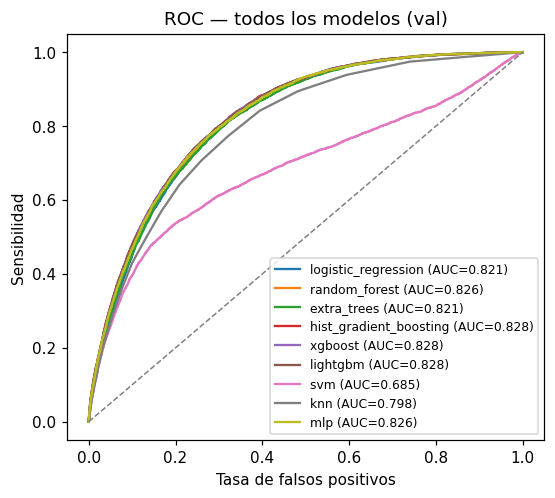

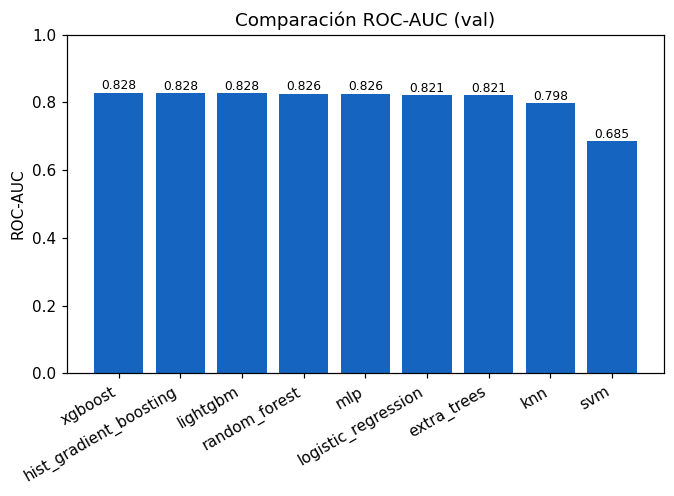

In [3]:
show(RES/'models'/'roc_all.png')
show(RES/'models'/'roc_auc_bar.png')

## Modelo seleccionado

Mejor modelo: xgboost | ROC-AUC(val)= 0.8283
Selección por ROC-AUC en val. Modelo lineal interpretable de referencia: logistic_regression.


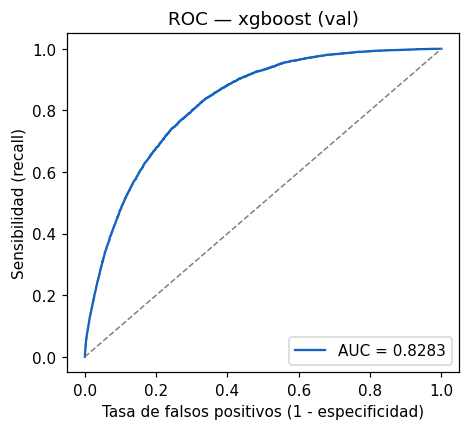

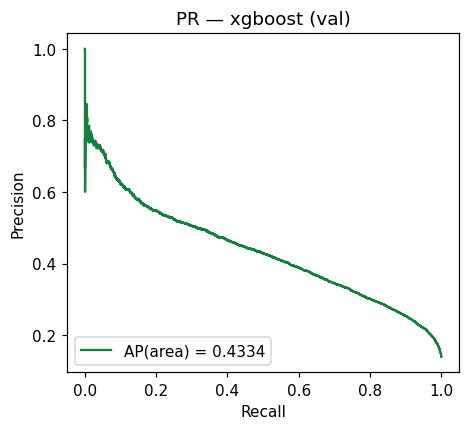

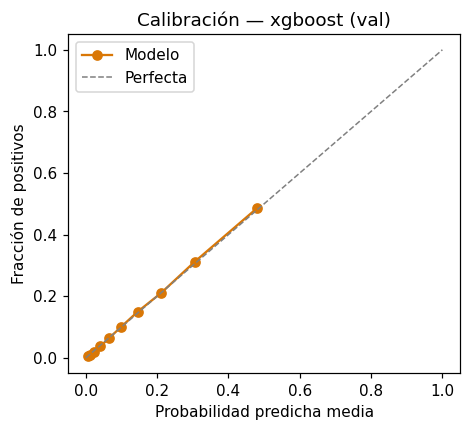

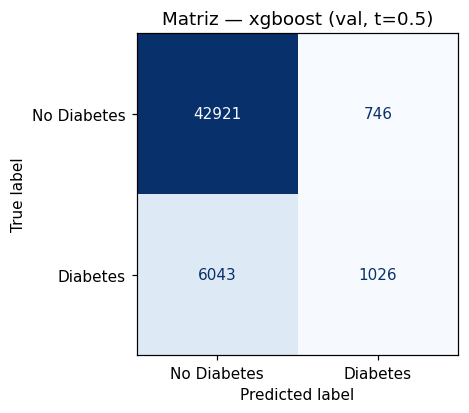

In [4]:
sel = load(RES/'models'/'selection.json')
best = sel['best_model']
print('Mejor modelo:', best, '| ROC-AUC(val)=', round(sel['best_roc_auc_val'],4))
print(sel['note'])
for p in ['roc','pr','calib','cm']:
    show(RES/'models'/f'{p}_{best}.png')

### Conclusiones Fase 1B
- Los modelos de *gradient boosting* y la regresión logística alcanzan ROC-AUC ~0.82–0.83, el techo razonable para indicadores auto-reportados del BRFSS (sin laboratorios).
- La regresión logística es competitiva y totalmente interpretable → excelente referencia clínica.
- Antes de fijar umbrales de riesgo, las probabilidades deben **calibrarse** (NB 03).